In [1]:
import duckdb
import polars as pl
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
con = duckdb.connect("../data/m5.db")

In [3]:
!pwd ../data/

/home/njimenez/Workspace/magister/forecast-tfm/notebooks


/home/njimenez/Workspace/magister/forecast-tfm/data/m5.db

In [4]:
con.execute("SHOW TABLES").fetchdf()

,name
0,calendar
1,dataset_raw
2,sales_train_evaluation
3,sales_train_validation
4,sample_submission
5,sell_prices


In [5]:
!ls ../data/processed/*

../data/processed/daily:
level_01_daily_total.parquet	  level_07_daily_state_dept.parquet
level_02_daily_state.parquet	  level_08_daily_store_cat.parquet
level_03_daily_cat.parquet	  level_09_daily_store_dept.parquet
level_04_daily_dept.parquet	  level_10_daily_item.parquet
level_05_daily_state_cat.parquet  level_11_daily_item_state.parquet
level_06_daily_store.parquet	  level_12_daily_item_store.parquet

../data/processed/weekly:
level_10_weekly_item.parquet	    level_12_weekly_item_store.parquet
level_11_weekly_item_state.parquet


In [6]:
DATASET_PATH = "../data/processed/level_12_daily_item_store.parquet"

In [7]:
YEAR = 2015

# Sample dataset

In [8]:
con.execute("SELECT * FROM dataset_raw LIMIT 3").fetchdf()

,series_id,state_id,store_id,cat_id,dept_id,item_id,date,sell_price,sales,mnt_gross_sales,snap,event_name,event_type
0,FOODS_1_001_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2011-01-29,2.0,3,6.0,0,None,None
1,FOODS_1_001_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2011-01-30,2.0,0,0.0,0,None,None
2,FOODS_1_001_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2011-01-31,2.0,0,0.0,0,None,None


In [9]:
con.execute("SELECT * FROM dataset_raw WHERE event_name != 'None' LIMIT 5").fetchdf()

,series_id,state_id,store_id,cat_id,dept_id,item_id,date,sell_price,sales,mnt_gross_sales,snap,event_name,event_type
0,FOODS_1_001_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2011-02-06,2.0,0,0.0,1,SuperBowl,Sporting
1,FOODS_1_001_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2011-02-14,2.0,2,4.0,0,ValentinesDay,Cultural
2,FOODS_1_001_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2011-02-21,2.0,0,0.0,0,PresidentsDay,National
3,FOODS_1_001_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2011-03-09,2.0,2,4.0,1,LentStart,Religious
4,FOODS_1_001_CA_1,CA,CA_1,FOODS,FOODS_1,FOODS_1_001,2011-03-16,2.0,1,2.0,0,LentWeek2,Religious


# By date

In [10]:
df_by_date = con.execute(f"""
    SELECT
    date,
    SUM(sales) AS sales
    FROM dataset_raw
    GROUP BY date
    ORDER BY date
""").df()

df_by_date

,date,sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0
...,...,...
1936,2016-05-18,37096.0
1937,2016-05-19,36963.0
1938,2016-05-20,42552.0
1939,2016-05-21,51518.0


# By year

In [11]:
df_dept_year = con.execute(f"""
    SELECT
        dept_id,
        EXTRACT(YEAR FROM date) AS year,
        SUM(mnt_gross_sales) AS total_gross_sales,
        COUNT(DISTINCT(date)) AS n_days
    FROM dataset_raw
    WHERE date >= '2011-02-01' and date < '2016-05-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

df_dept_year['total_gross_sales_pct'] = df_dept_year['total_gross_sales'] / df_dept_year.groupby('year')['total_gross_sales'].transform('sum')
df_dept_year.head()

,dept_id,year,total_gross_sales,n_days,total_gross_sales_pct
0,FOODS_1,2011,1542900.32,334,0.065176
1,FOODS_1,2012,2367583.16,366,0.072516
2,FOODS_1,2013,2517121.27,365,0.070069
3,FOODS_1,2014,2571890.70,365,0.067928
4,FOODS_1,2015,2909513.26,365,0.068594


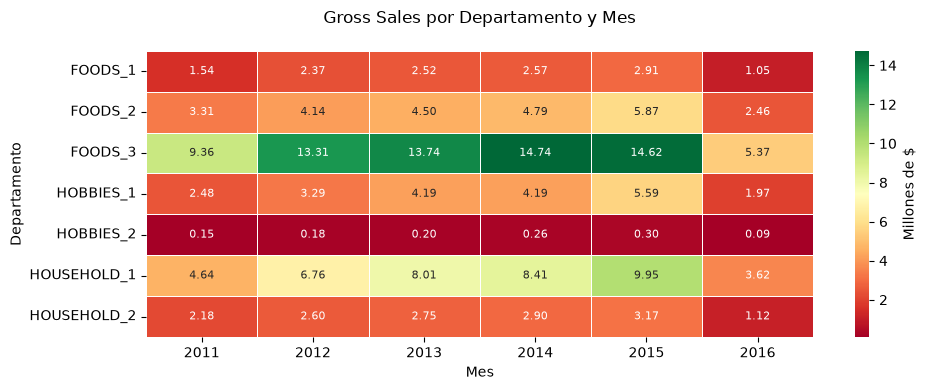

In [12]:
df_plot = df_dept_year.pivot(index='dept_id', columns='year', values='total_gross_sales')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot / 1e6, cmap='RdYlGn', annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Millones de $'}
)
plt.title(f'Gross Sales por Departamento y Mes', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Departamento')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
df_store_year = con.execute(f"""
    SELECT
        store_id,
        EXTRACT(YEAR FROM date) AS year,
        SUM(mnt_gross_sales) AS total_gross_sales,
        COUNT(DISTINCT(date)) AS n_days
    FROM dataset_raw
    WHERE date >= '2011-02-01' and date < '2016-05-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

df_store_year['total_gross_sales_pct'] = df_store_year['total_gross_sales'] / df_store_year.groupby('year')['total_gross_sales'].transform('sum')
df_store_year.head()

,store_id,year,total_gross_sales,n_days,total_gross_sales_pct
0,CA_1,2011,2894324.26,334,0.122263
1,CA_1,2012,3917812.66,366,0.119997
2,CA_1,2013,4342793.28,365,0.120890
3,CA_1,2014,4645767.19,365,0.122703
4,CA_1,2015,5058086.52,365,0.119248


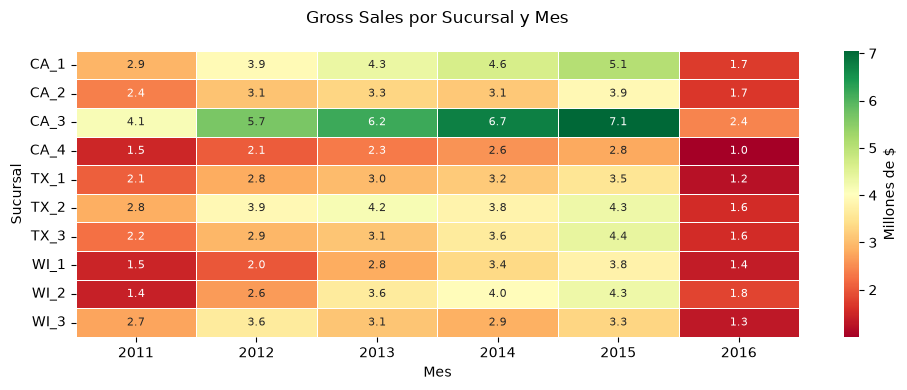

In [14]:
df_plot = df_store_year.pivot(index='store_id', columns='year', values='total_gross_sales')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot / 1e6, cmap='RdYlGn', annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Millones de $'}
)
plt.title(f'Gross Sales por Sucursal y Mes', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Sucursal')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# By Month

In [15]:
df_month_year = con.execute(f"""
    SELECT
        EXTRACT(YEAR FROM date) AS year,
        EXTRACT(MONTH FROM date) AS month,
        SUM(mnt_gross_sales) AS total_gross_sales,
        COUNT(DISTINCT(date)) AS n_days
    FROM dataset_raw
    WHERE date >= '2011-02-01' and date < '2016-05-01'
    GROUP BY 1, 2
    ORDER BY 1, 2
""").df()

df_month_year['total_gross_sales_pct'] = df_month_year['total_gross_sales'] / df_month_year.groupby('year')['total_gross_sales'].transform('sum')
df_month_year.head()

,year,month,total_gross_sales,n_days,total_gross_sales_pct
0,2011,2,1925877.70,28,0.081353
1,2011,3,2052900.47,31,0.086719
2,2011,4,2027413.92,30,0.085642
3,2011,5,2002988.04,31,0.084611
4,2011,6,2071718.02,30,0.087514


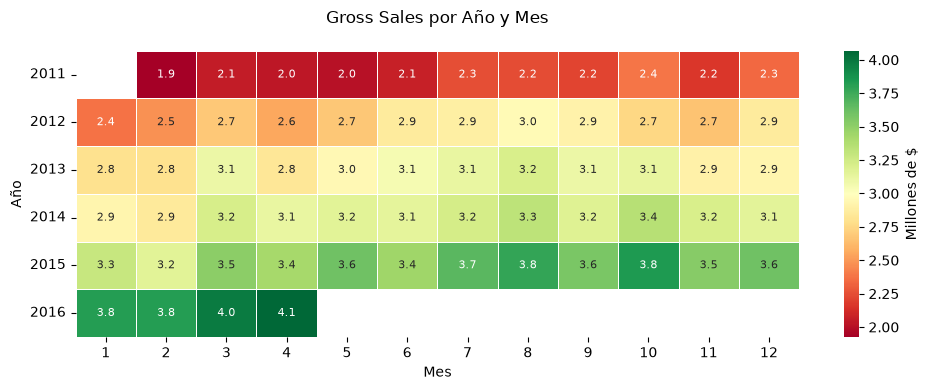

In [16]:
df_plot = df_month_year.pivot(index='year', columns='month', values='total_gross_sales')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot / 1e6, cmap='RdYlGn', annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': 'Millones de $'}
)
plt.title(f'Gross Sales por Año y Mes', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Año')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Dept - Month

In [17]:
df_dept_month = con.execute(f"""
    SELECT
        dept_id,
        strftime(date, '%Y-%m') AS year_month,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY dept_id, year_month
    ORDER BY dept_id, year_month
""").df()

df_dept_month['total_gross_sales_pct'] = df_dept_month['total_gross_sales'] / df_dept_month.groupby('dept_id')['total_gross_sales'].transform('sum')
df_dept_month

,dept_id,year_month,total_gross_sales,total_gross_sales_pct
0,FOODS_1,2015-01,238684.20,0.082036
1,FOODS_1,2015-02,224035.82,0.077001
2,FOODS_1,2015-03,214346.41,0.073671
3,FOODS_1,2015-04,227795.81,0.078293
4,FOODS_1,2015-05,245546.49,0.084394
...,...,...,...,...
79,HOUSEHOLD_2,2015-08,299684.79,0.094497
80,HOUSEHOLD_2,2015-09,250424.32,0.078964
81,HOUSEHOLD_2,2015-10,263914.51,0.083218
82,HOUSEHOLD_2,2015-11,242463.18,0.076454


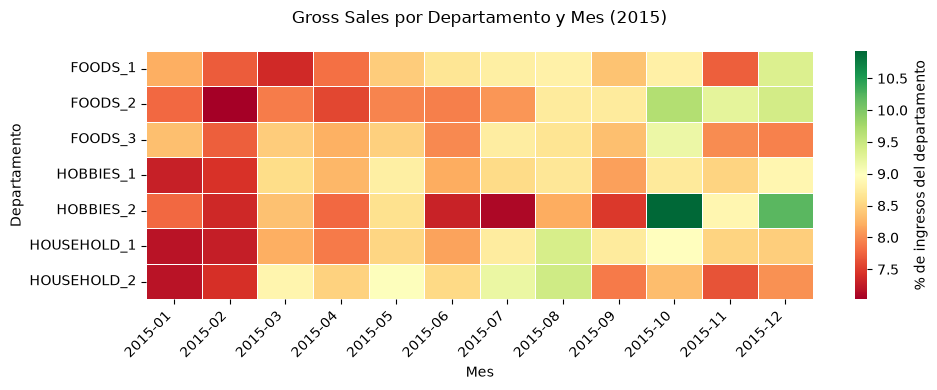

In [18]:
df_plot = df_dept_month.pivot(index='dept_id', columns='year_month', values='total_gross_sales_pct')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot * 100, cmap='RdYlGn', annot=False, linewidths=0.5,
    cbar_kws={'label': '% de ingresos del departamento'}
)
plt.title(f'Gross Sales por Departamento y Mes ({YEAR})', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Departamento')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

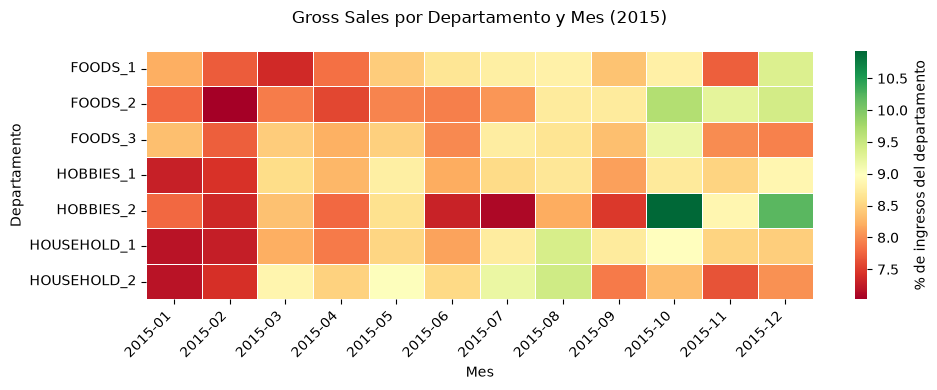

In [19]:
df_plot = df_dept_month.pivot(index='dept_id', columns='year_month', values='total_gross_sales_pct')

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot * 100, cmap='RdYlGn', annot=False, linewidths=0.5,
    cbar_kws={'label': '% de ingresos del departamento'}
)
plt.title(f'Gross Sales por Departamento y Mes ({YEAR})', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Departamento')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Store - month

In [20]:
df_store_month = con.execute(f"""
    SELECT
        store_id,
        strftime(date, '%Y-%m') AS year_month,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY store_id, year_month
    ORDER BY store_id, year_month
""").df()

df_store_month['total_gross_sales_pct'] = df_store_month['total_gross_sales'] / df_store_month.groupby('store_id')['total_gross_sales'].transform('sum')

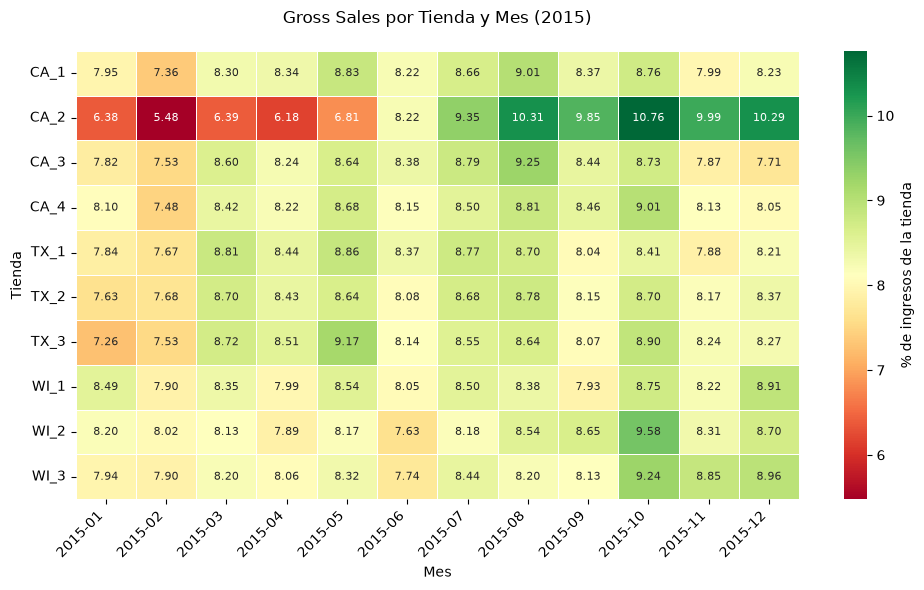

In [21]:
df_plot = df_store_month.pivot(index='store_id', columns='year_month', values='total_gross_sales_pct')

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    df_plot * 100,
    cmap='RdYlGn',
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': '% de ingresos de la tienda'}
)
plt.title(f'Gross Sales por Tienda y Mes ({YEAR})', pad=20, fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Tienda')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

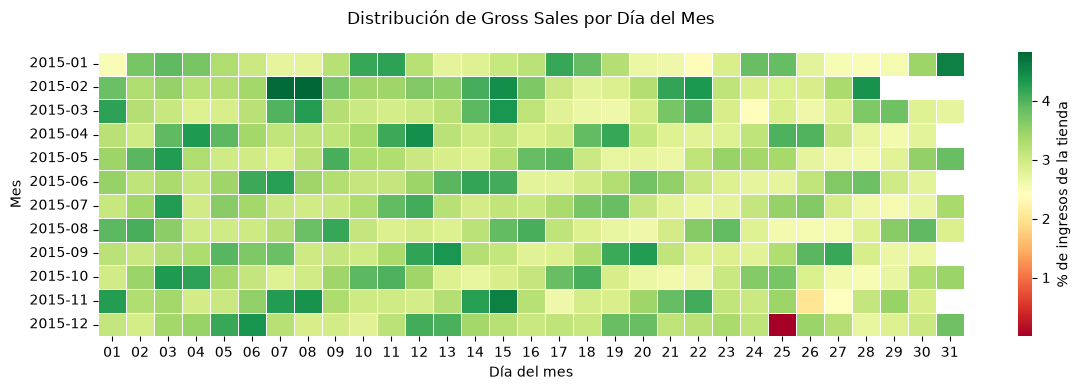

In [22]:
df_day_month = con.execute(f"""
    SELECT
        strftime(date, '%d') AS day,
        strftime(date, '%Y-%m') AS year_month,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY strftime(date, '%d'), strftime(date, '%Y-%m')
    ORDER BY year_month, day
""").df()

df_day_month['total_gross_sales_pct'] = (
    df_day_month.groupby('year_month')['total_gross_sales']
    .transform(lambda x: x / x.sum())
)

df_plot = df_day_month.pivot(index='year_month', columns='day', values='total_gross_sales_pct')

plt.figure(figsize=(12, 4))
ax = sns.heatmap(
    df_plot * 100,
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': '% de ingresos de la tienda'}
)
plt.title('Distribución de Gross Sales por Día del Mes', pad=20, fontsize=12)
plt.xlabel('Día del mes')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

# Day of the week

## Store - DOW

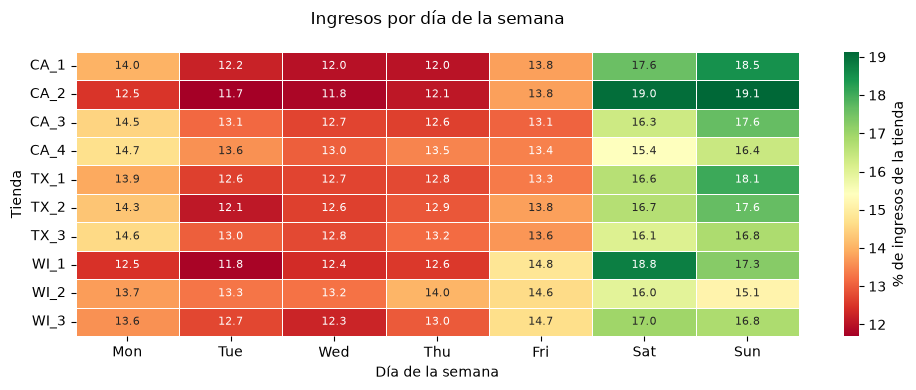

In [23]:
df_store_dow = con.execute(f"""
    SELECT
        store_id,
        strftime(date, '%a') AS day_of_week,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY store_id, strftime(date, '%a')
    ORDER BY store_id, day_of_week
""").df()

df_store_dow['total_gross_sales_pct'] = (
    df_store_dow.groupby('store_id')['total_gross_sales']
    .transform(lambda x: x / x.sum())
)

dow_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_plot = df_store_dow.pivot(index='store_id', columns='day_of_week', values='total_gross_sales_pct')
df_plot = df_plot[dow_order]

plt.figure(figsize=(10, 4))
ax = sns.heatmap(
    df_plot * 100,
    cmap='RdYlGn',
    annot=True, fmt='.1f', annot_kws={'size': 8},
    linewidths=0.5,
    cbar_kws={'label': '% de ingresos de la tienda'}
)
plt.title('Ingresos por día de la semana', pad=20, fontsize=12)
plt.xlabel('Día de la semana')
plt.ylabel('Tienda')
plt.yticks(rotation=0)
plt.xticks(rotation=0,)
plt.tight_layout()
plt.show()

# Depts

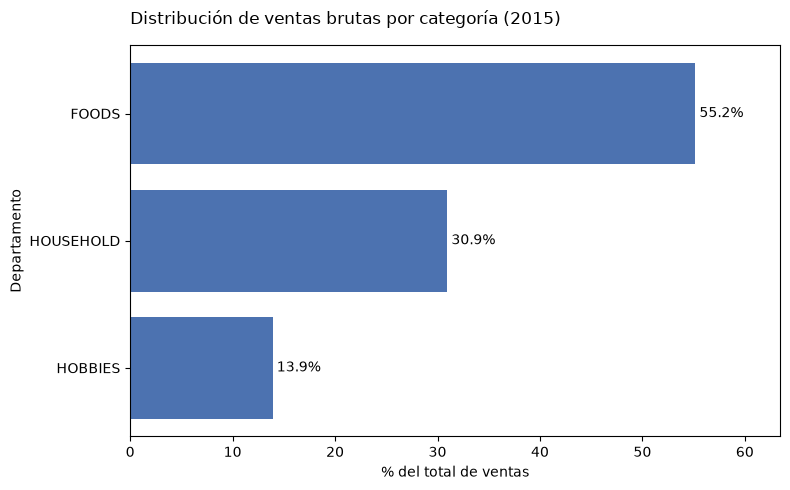

In [24]:
df_cat = con.execute(f"""
    SELECT
        cat_id,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY 1
    ORDER BY 1
""").df()

df_cat['total_gross_sales_pct'] = df_cat['total_gross_sales'] / df_cat['total_gross_sales'].sum()

df_cat_sorted = df_cat.sort_values('total_gross_sales_pct', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_cat_sorted['cat_id'], df_cat_sorted['total_gross_sales_pct'] * 100, color='#4C72B0')
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xlabel('% del total de ventas')
plt.ylabel('Departamento')
plt.title(f'Distribución de ventas brutas por categoría ({YEAR})', loc='left', pad=15, fontsize=12)
plt.xlim(0, df_cat_sorted['total_gross_sales_pct'].max() * 100 * 1.15)  # deja espacio extra para el label
plt.tight_layout()
plt.show()

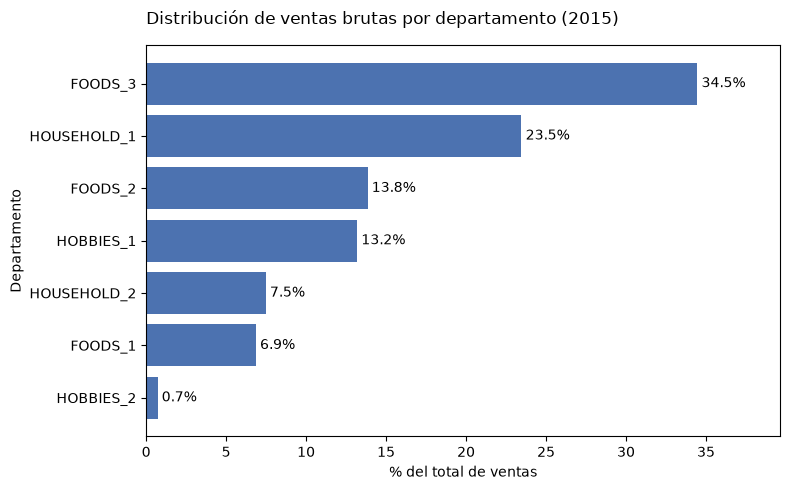

In [25]:
df_dept = con.execute(f"""
    SELECT
        dept_id,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY 1
    ORDER BY 1
""").df()

df_dept['total_gross_sales_pct'] = df_dept['total_gross_sales'] / df_dept['total_gross_sales'].sum()

df_dept_sorted = df_dept.sort_values('total_gross_sales_pct', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_dept_sorted['dept_id'], df_dept_sorted['total_gross_sales_pct'] * 100, color='#4C72B0')
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xlabel('% del total de ventas')
plt.ylabel('Departamento')
plt.title(f'Distribución de ventas brutas por departamento ({YEAR})', loc='left', pad=15, fontsize=12)
plt.xlim(0, df_dept_sorted['total_gross_sales_pct'].max() * 100 * 1.15)  # deja espacio extra para el label
plt.tight_layout()
plt.show()

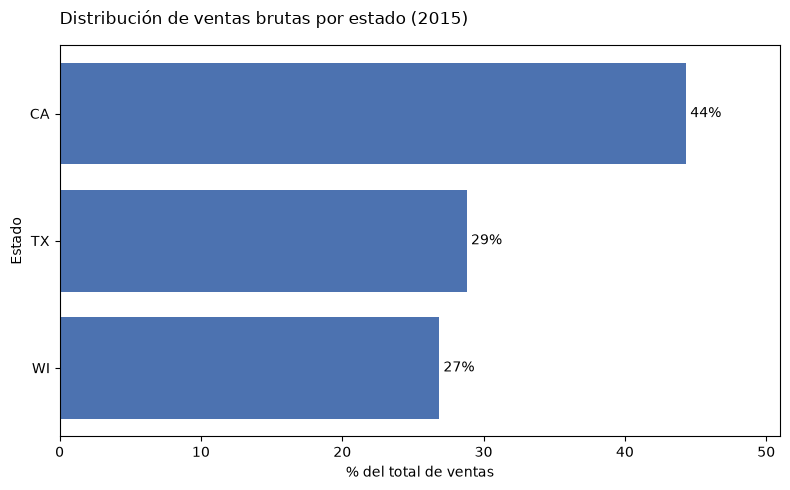

In [26]:
df_state = con.execute(f"""
    SELECT
        state_id,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY 1
    ORDER BY 1
""").df()

df_state['total_gross_sales_pct'] = df_state['total_gross_sales'] / df_state['total_gross_sales'].sum()

df_state_sorted = df_state.sort_values('total_gross_sales_pct', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_state_sorted['state_id'], df_state_sorted['total_gross_sales_pct'] * 100, color='#4C72B0')
plt.bar_label(bars, fmt='%.0f%%', padding=3)
plt.xlabel('% del total de ventas')
plt.ylabel('Estado')
plt.title(f'Distribución de ventas brutas por estado ({YEAR})', loc='left', pad=15, fontsize=12)
plt.xlim(0, df_state_sorted['total_gross_sales_pct'].max() * 100 * 1.15)
plt.tight_layout()
plt.show()

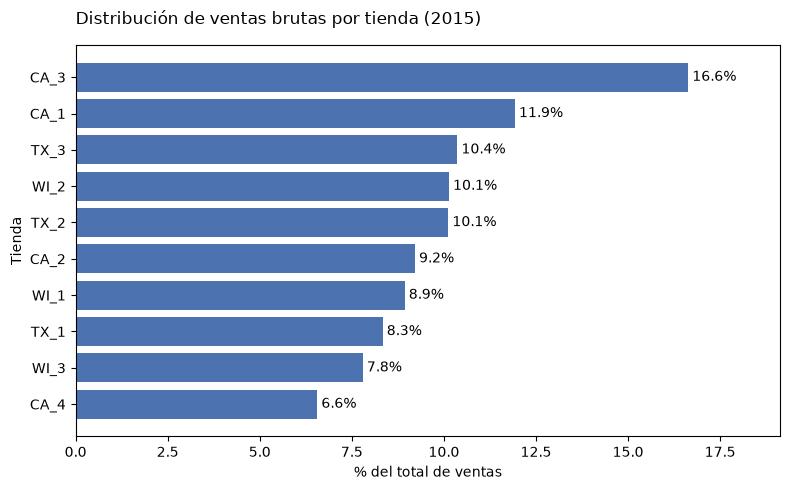

In [27]:
df_store = con.execute(f"""
    SELECT
        state_id,
        store_id,
        SUM(mnt_gross_sales) AS total_gross_sales
    FROM dataset_raw
    WHERE date >= '{YEAR}-01-01' AND date < '{YEAR+1}-01-01'
    GROUP BY 1,2
    ORDER BY 1,2
""").df()

df_store['total_gross_sales_pct'] = df_store['total_gross_sales'] / df_store['total_gross_sales'].sum()

df_store_sorted = df_store.sort_values('total_gross_sales_pct', ascending=True)

plt.figure(figsize=(8, 5))
bars = plt.barh(df_store_sorted['store_id'], df_store_sorted['total_gross_sales_pct'] * 100, color='#4C72B0')
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.xlabel('% del total de ventas')
plt.ylabel('Tienda')
plt.title(f'Distribución de ventas brutas por tienda ({YEAR})', loc='left', pad=15, fontsize=12)
plt.xlim(0, df_store_sorted['total_gross_sales_pct'].max() * 100 * 1.15)
plt.tight_layout()
plt.show()

In [28]:
df_store.to_clipboard(index=False, sep='\t', decimal=',')

# Niveles de agregación

In [29]:
!ls ../data/processed/

daily  weekly


In [30]:
import os

dir = "../data/processed/daily/"
levels = os.listdir(dir)
levels.sort()
levels

['level_01_daily_total.parquet',
 'level_02_daily_state.parquet',
 'level_03_daily_cat.parquet',
 'level_04_daily_dept.parquet',
 'level_05_daily_state_cat.parquet',
 'level_06_daily_store.parquet',
 'level_07_daily_state_dept.parquet',
 'level_08_daily_store_cat.parquet',
 'level_09_daily_store_dept.parquet',
 'level_10_daily_item.parquet',
 'level_11_daily_item_state.parquet',
 'level_12_daily_item_store.parquet']

In [31]:
duckdb.sql('')

In [32]:
df_level_stats = pd.DataFrame()

for level in levels:
    path = dir + level
    partes = level.split(sep='_')
    level_label = partes[0] + "_" + partes[1]
    df_level = duckdb.sql(
        f"""
        SELECT
            COUNT(DISTINCT(state_id)) AS n_states,
            COUNT(DISTINCT(store_id)) AS n_stores,
            COUNT(DISTINCT(cat_id)) AS n_cat,
            COUNT(DISTINCT(dept_id)) AS n_dept,
            COUNT(DISTINCT(item_id)) AS n_items,
            COUNT(DISTINCT(agg_id)) AS n_series,
            COUNT(DISTINCT(date)) AS ndays,
            COUNT(*) AS n_rows
        FROM '{path}'
        """
    ).fetchdf()
    df_level['level'] = level_label
    df_level = df_level.set_index('level')
    df_level_stats = pd.concat([df_level_stats, df_level])

df_level_stats[['n_cat','n_dept','n_states','n_stores', 'n_items']] = df_level_stats[['n_cat','n_dept','n_states','n_stores', 'n_items']].replace(1, np.nan)

df_level_stats.to_clipboard(index=False)
df_level_stats

,n_states,n_stores,n_cat,n_dept,n_items,n_series,ndays,n_rows
level,,,,,,,,
level_01,NaN,NaN,NaN,NaN,NaN,1,1941,1941
level_02,3.0,NaN,NaN,NaN,NaN,3,1941,5823
level_03,NaN,NaN,3.0,NaN,NaN,3,1941,5823
level_04,NaN,NaN,3.0,7.0,NaN,7,1941,13587
level_05,3.0,NaN,3.0,NaN,NaN,9,1941,17469
level_06,3.0,10.0,NaN,NaN,NaN,10,1941,19410
level_07,3.0,NaN,3.0,7.0,NaN,21,1941,40761
level_08,3.0,10.0,3.0,NaN,NaN,30,1941,58230
level_09,3.0,10.0,3.0,7.0,NaN,70,1941,135870


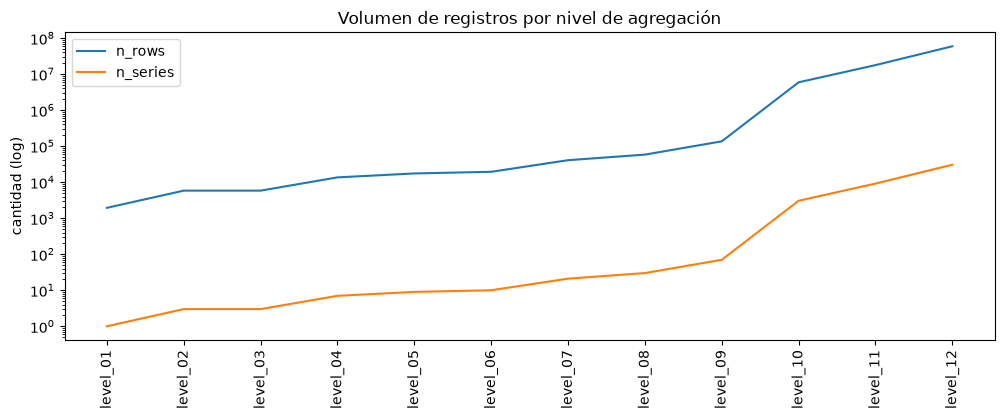

In [33]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(data=df_level_stats, x=df_level_stats.index, y='n_rows', label='n_rows', ax=ax)
sns.lineplot(data=df_level_stats, x=df_level_stats.index, y='n_series', label='n_series', ax=ax)

ax.set_yscale('log')
ax.set_title('Volumen de registros por nivel de agregación')
plt.xticks(rotation=90)
plt.ylabel('cantidad (log)')
plt.xlabel('')
plt.legend()
plt.show()

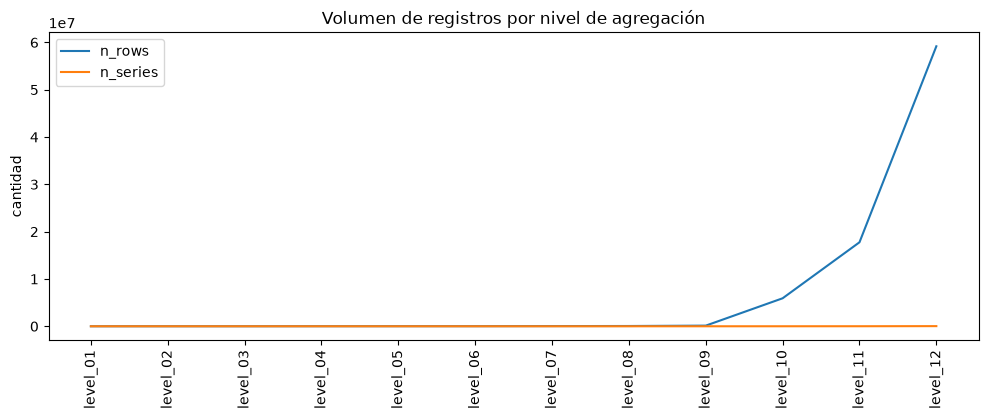

In [34]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.lineplot(data=df_level_stats, x=df_level_stats.index, y='n_rows', label='n_rows', ax=ax)
sns.lineplot(data=df_level_stats, x=df_level_stats.index, y='n_series', label='n_series', ax=ax)

ax.set_title('Volumen de registros por nivel de agregación')
plt.xticks(rotation=90)
plt.ylabel('cantidad')
plt.xlabel('')
plt.legend()
plt.show()

# Demanda